## Modelos de Duração v2 — Kaplan-Meier por Competitividade do Partido

Replica `cap3_survival_km_cs.png` e `cap3_survival_km_maior_cs.png`, acrescentando
uma segunda dimensão de corte: **competitividade do partido (ex-ante)**.

**Definição de partido competitivo (ex-ante):** bancada nacional ≥ 20 cadeiras na
data de início do período de convenções (2014-06-10 / 2018-07-20 / 2022-07-20),
consultada via API da Câmara (`bancada_partido_uf.csv`).  
Diferentemente de `tipo_partido` em `cap3_cs_features.py` (que usa cadeiras ganhas
na eleição corrente — ex-post), esta medida é **estritamente pré-eleitoral**.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path().resolve().parent  # notebooks/ -> project root
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src' / '2_gold'))

In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

ROOT      = Path().resolve()
DATA_PATH = ROOT / "data" / "processed"
pio.renderers.default = "png"

In [3]:
from cap3_survival_features import (
    gerar_features_survival,
    preparar_survival,
    JANELAS, DURACAO, FONTES_PARTIDO,
    ARQUIVOS_RECEITAS, ler_tab_receitas, tratar_df_receita,
    carregar_receitas, calcular_dias_maior_receita, preparar_survival_maior,
    COVS_MODELO,
)

In [4]:
ELEITO_CATS = ["ELEITO", "ELEITO POR MEDIA", "MEDIA", "ELEITO POR QP"]

rrd = pd.read_parquet(DATA_PATH / "rrd_df_novo.parquet")
rrd["nr_candidato"] = rrd["nr_candidato"].astype(str)
rrd["dias_primeira_receita"] = rrd["dias_desde_inicio"]
rrd["eleito"] = rrd["ds_sit_tot_turno"].isin(ELEITO_CATS).astype(int)

rrd_df = gerar_features_survival(rrd)
print(f"RRD carregado: {len(rrd_df):,} candidatos")

RRD carregado: 23,483 candidatos


### Construção de `partido_competitivo` (ex-ante)

**Harmonização de nomes Câmara API → TSE necessária:**

| Bancada CSV | TSE (`rrd`) | Anos afetados |
|---|---|---|
| `PP**` | `PP` | 2014, 2018 |
| `PCdoB` | `PC do B` | 2014, 2018 |
| `SD` | `SOLIDARIEDADE` | 2018 (rrd 2014 ainda usa `SD`) |

O nome `UNIÃO` apresenta mesmo encoding nos dois datasets — join direto funciona.

In [5]:
bancada = pd.read_csv(DATA_PATH / "bancada_partido_uf.csv")

# Harmonização: Câmara API → TSE
# PP** e PCdoB: todos os anos
# SD → SOLIDARIEDADE: apenas 2018 (rrd 2014 usa "SD")
HARMONIZE_GERAL = {"PP**": "PP", "PCdoB": "PC do B"}
HARMONIZE_2018  = {"SD": "SOLIDARIEDADE"}

bancada["sg_partido"] = bancada["sg_partido"].replace(HARMONIZE_GERAL)
bancada.loc[bancada["ano_eleicao"] == 2018, "sg_partido"] = (
    bancada.loc[bancada["ano_eleicao"] == 2018, "sg_partido"].replace(HARMONIZE_2018)
)

LIMIAR_CADEIRAS = 20
bancada_nat = (
    bancada.groupby(["ano_eleicao", "sg_partido"])["n_deputados"]
    .sum()
    .reset_index()
    .rename(columns={"n_deputados": "cadeiras_pre_eleicao"})
)
bancada_nat["partido_competitivo"] = bancada_nat["cadeiras_pre_eleicao"] >= LIMIAR_CADEIRAS

rrd_df = rrd_df.merge(
    bancada_nat[["ano_eleicao", "sg_partido", "cadeiras_pre_eleicao", "partido_competitivo"]],
    on=["ano_eleicao", "sg_partido"],
    how="left",
)
rrd_df["partido_competitivo"] = rrd_df["partido_competitivo"].fillna(False)

print("candidatos por ano e competitividade do partido:")
print(
    rrd_df.groupby(["ano_eleicao", "partido_competitivo"]).size()
    .rename("n_candidatos").reset_index().to_string(index=False)
)

candidatos por ano e competitividade do partido:
 ano_eleicao  partido_competitivo  n_candidatos
        2014                False          3996
        2014                 True          2182
        2018                False          5598
        2018                 True          2032
        2022                False          5757
        2022                 True          3918


In [6]:
print(f"Limiar: ≥{LIMIAR_CADEIRAS} cadeiras nacionais pré-eleição\n")
for ano in [2014, 2018, 2022]:
    tab = (
        bancada_nat[bancada_nat.ano_eleicao == ano]
        .sort_values("cadeiras_pre_eleicao", ascending=False)
        .assign(competitivo=lambda d: d["partido_competitivo"].map({True: "✓", False: ""}))
        [["sg_partido", "cadeiras_pre_eleicao", "competitivo"]]
    )
    print(f"--- {ano} ---")
    print(tab.to_string(index=False))
    print()

Limiar: ≥20 cadeiras nacionais pré-eleição

--- 2014 ---
sg_partido  cadeiras_pre_eleicao competitivo
        PT                    86           ✓
      PMDB                    69           ✓
      PSDB                    44           ✓
       PSD                    44           ✓
        PP                    39           ✓
        PR                    32           ✓
       DEM                    28           ✓
       PSB                    22           ✓
        SD                    20           ✓
      PROS                    18            
       PDT                    17            
       PTB                    17            
   PC do B                    15            
       PSC                    12            
       PRB                     9            
        PV                     8            
       PPS                     6            
      PSOL                     3            
     PTdoB                     3            
       PRP                     2           

In [7]:

# cs_lookup: chave para re-merge após preparar_survival
cs_lookup = rrd_df[
    ["ano_eleicao", "sg_uf", "sg_partido", "nr_candidato",
     "candidato_competitivo", "partido_competitivo"]
].drop_duplicates()

# preparar_survival seleciona colunas específicas e perde candidato/partido_competitivo
survival_dfs = {ano: preparar_survival(rrd_df, ano) for ano in [2018, 2022]}

for ano in [2018, 2022]:
    key = (
        cs_lookup[cs_lookup["ano_eleicao"] == ano]
        [["sg_uf", "sg_partido", "nr_candidato", "candidato_competitivo", "partido_competitivo"]]
        .drop_duplicates()
    )
    survival_dfs[ano] = survival_dfs[ano].merge(
        key, on=["sg_uf", "sg_partido", "nr_candidato"], how="left"
    )
    survival_dfs[ano]["partido_competitivo"]   = survival_dfs[ano]["partido_competitivo"].fillna(False)
    survival_dfs[ano]["candidato_competitivo"] = survival_dfs[ano]["candidato_competitivo"].fillna(False)

df_surv_18, df_surv_22 = survival_dfs[2018], survival_dfs[2022]

for ano, df in survival_dfs.items():
    ev = int(df["event"].sum())
    n_comp = df["partido_competitivo"].sum()
    print(f"{ano} — N={len(df):,} | eventos={ev:,} ({ev/len(df)*100:.0f}%) | em partidos comp.={n_comp:,} ({n_comp/len(df)*100:.0f}%)")


2018 — N=7,626 | eventos=5,336 (70%) | em partidos comp.=2,029 (27%)
2022 — N=9,616 | eventos=8,514 (89%) | em partidos comp.=3,917 (41%)


In [8]:

def _km_1822(df_surv, ano):
    d = df_surv.copy()
    d["candidato_competitivo"] = d["candidato_competitivo"].fillna(False)
    d["partido_competitivo"]   = d["partido_competitivo"].fillna(False)
    d["grupo_cs"]        = d["candidato_competitivo"].map(
        {True: "Candidato competitivo", False: "Candidato não-competitivo"}
    )
    d["duration_semana"] = (d["duration"] / 7).clip(upper=DURACAO[ano] / 7)
    return d


PAINEIS = [
    ("2018", _km_1822(df_surv_18, 2018)),
    ("2022", _km_1822(df_surv_22, 2022)),
]

print("Painéis construídos:")
for titulo, d in PAINEIS:
    n_comp = d["partido_competitivo"].sum()
    print(f"  {titulo}: N={len(d):,} | partidos comp.={n_comp:,} ({n_comp/len(d)*100:.0f}%)")


Painéis construídos:
  2018: N=7,626 | partidos comp.=2,029 (27%)
  2022: N=9,616 | partidos comp.=3,917 (41%)


### Figura KM 1 — Timing do Primeiro Repasse

Layout 4 × 3:
- Linhas 1–2: candidatos em **partidos competitivos** (≥20 cadeiras pré-eleição)
- Linhas 3–4: candidatos em **partidos menos competitivos**

Cada par de linhas replica o layout original (2×3 com célula vazia em col 3 da linha par).
Curvas dentro de cada painel: candidato competitivo vs. não-competitivo (ex-ante).

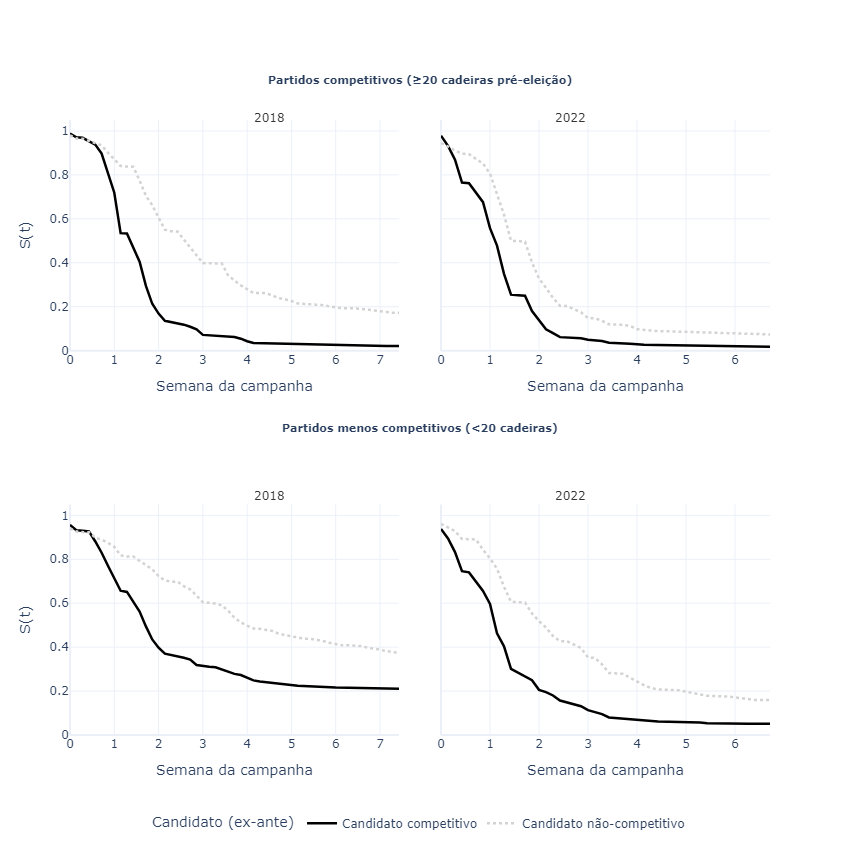

In [9]:

cores_km  = {"Candidato competitivo": "black",    "Candidato não-competitivo": "lightgrey"}
dashes_km = {"Candidato competitivo": "solid",     "Candidato não-competitivo": "dot"}
grupos_km = ["Candidato competitivo", "Candidato não-competitivo"]

TIPO_LABELS = {
    True:  "Partidos competitivos (≥20 cadeiras pré-eleição)",
    False: "Partidos menos competitivos (<20 cadeiras)",
}

# 2×2 grid: linha 1 = partidos competitivos | linha 2 = partidos menos competitivos
painel_names = [p[0] for p in PAINEIS]

fig_km = make_subplots(
    rows=2, cols=2,
    shared_yaxes=True,
    vertical_spacing=0.25,
    horizontal_spacing=0.06,
)

# Mapeamento painel → (row, col) dentro de um bloco de 1×2
POS_BLOCO = {0: (1, 1), 1: (1, 2)}

for i_tipo, tipo in enumerate([True, False]):
    row_offset = i_tipo * 1
    for i_painel, (titulo, d_base) in enumerate(PAINEIS):
        r_bloco, c = POS_BLOCO[i_painel]
        row, col = r_bloco + row_offset, c
        d = d_base[d_base["partido_competitivo"] == tipo].copy()

        for grupo in grupos_km:
            mask = d["grupo_cs"] == grupo
            if mask.sum() < 5:
                continue
            kmf = KaplanMeierFitter()
            kmf.fit(d.loc[mask, "duration_semana"],
                    event_observed=d.loc[mask, "event"], label=grupo)
            sf = kmf.survival_function_
            fig_km.add_trace(
                go.Scatter(
                    x=kmf.timeline, y=sf[grupo].values,
                    mode="lines", name=grupo,
                    legendgroup=grupo,
                    showlegend=(i_tipo == 0 and i_painel == 0),
                    line=dict(color=cores_km[grupo], width=2.5, dash=dashes_km[grupo]),
                ),
                row=row, col=col,
            )

# Cabeçalhos horizontais de linha
fig_km.add_annotation(
    x=0.5, xref="paper", y=1.08, yref="paper",
    text=f"<b>{TIPO_LABELS[True]}</b>",
    showarrow=False, font=dict(size=11), align="center",
)
fig_km.add_annotation(
    x=0.5, xref="paper", y=0.50, yref="paper",
    text=f"<b>{TIPO_LABELS[False]}</b>",
    showarrow=False, font=dict(size=11), align="center",
)

# Rótulos de ano acima de cada subplot
# col midpoints com horizontal_spacing=0.06, 2 cols: ~0.26 | ~0.74
COL_MIDS = [0.26, 0.74]
for y_label in [1.02, 0.39]:
    for x_mid, nome in zip(COL_MIDS, painel_names):
        fig_km.add_annotation(
            x=x_mid, xref="paper", y=y_label, yref="paper",
            text=nome, showarrow=False,
            font=dict(size=12, color="#333"), align="center",
        )

fig_km.update_layout(
    legend=dict(
        title="Candidato (ex-ante)",
        orientation="h", x=0.5, xanchor="center", y=-0.12, yanchor="top",
    ),
    height=850, width=850, template="plotly_white",
    margin=dict(t=120, b=90, l=70),
)
fig_km.update_xaxes(title_text="Semana da campanha", dtick=1)
fig_km.update_yaxes(title_text="S(t)", range=[0, 1.05], col=1)

fig_km.write_image("figs/cap3_survival_km_cs_v2.png", scale=2)
fig_km.show(config={"staticPlot": True})


### Figura KM 2 — Timing do Maior Repasse (robustez)

Mesma estrutura 4×3, mas usando como evento o dia do **maior repasse diário** de recursos
partidários (FP/PJ_ROTEADO/FEFC) em vez do primeiro repasse.

In [10]:
# Carrega dados transacionais (pesado — reutilizar se já em memória)
_df_rec_all     = carregar_receitas()
_df_rec_partido = _df_rec_all[_df_rec_all["fonte_tipo"].isin(FONTES_PARTIDO)].copy()

df_maior = calcular_dias_maior_receita(_df_rec_partido)
print("Candidatos com maior repasse por ano:")
print(df_maior.groupby("ano_eleicao").size().rename("n"))

Candidatos com maior repasse por ano:
ano_eleicao
2014    2356
2018    5830
2022    8596
Name: n, dtype: int64


In [11]:

survival_maior = {
    ano: preparar_survival_maior(rrd_df, df_maior, ano)
    for ano in [2018, 2022]
}

# Re-merge partido_competitivo e candidato_competitivo
for ano in [2018, 2022]:
    key = (
        cs_lookup[cs_lookup["ano_eleicao"] == ano]
        [["sg_uf", "sg_partido", "nr_candidato", "candidato_competitivo", "partido_competitivo"]]
        .drop_duplicates()
    )
    survival_maior[ano] = survival_maior[ano].merge(
        key, on=["sg_uf", "sg_partido", "nr_candidato"], how="left"
    )
    survival_maior[ano]["partido_competitivo"]   = survival_maior[ano]["partido_competitivo"].fillna(False)
    survival_maior[ano]["candidato_competitivo"] = survival_maior[ano]["candidato_competitivo"].fillna(False)

for ano, df in survival_maior.items():
    ev = int(df["event"].sum())
    print(f"{ano} — N={len(df):,} | eventos={ev:,} ({ev/len(df)*100:.0f}%)")


2018 — N=7,626 | eventos=5,281 (69%)
2022 — N=9,616 | eventos=8,318 (87%)


In [12]:

def _km_maior_1822(df_surv_m, ano):
    d = df_surv_m.copy()
    d["candidato_competitivo"] = d["candidato_competitivo"].fillna(False)
    d["partido_competitivo"]   = d["partido_competitivo"].fillna(False)
    d["grupo_cs"]        = d["candidato_competitivo"].map(
        {True: "Candidato competitivo", False: "Candidato não-competitivo"}
    )
    d["duration_semana"] = (d["duration"] / 7).clip(upper=DURACAO[ano] / 7)
    return d


PAINEIS_MAIOR = [
    ("2018", _km_maior_1822(survival_maior[2018], 2018)),
    ("2022", _km_maior_1822(survival_maior[2022], 2022)),
]


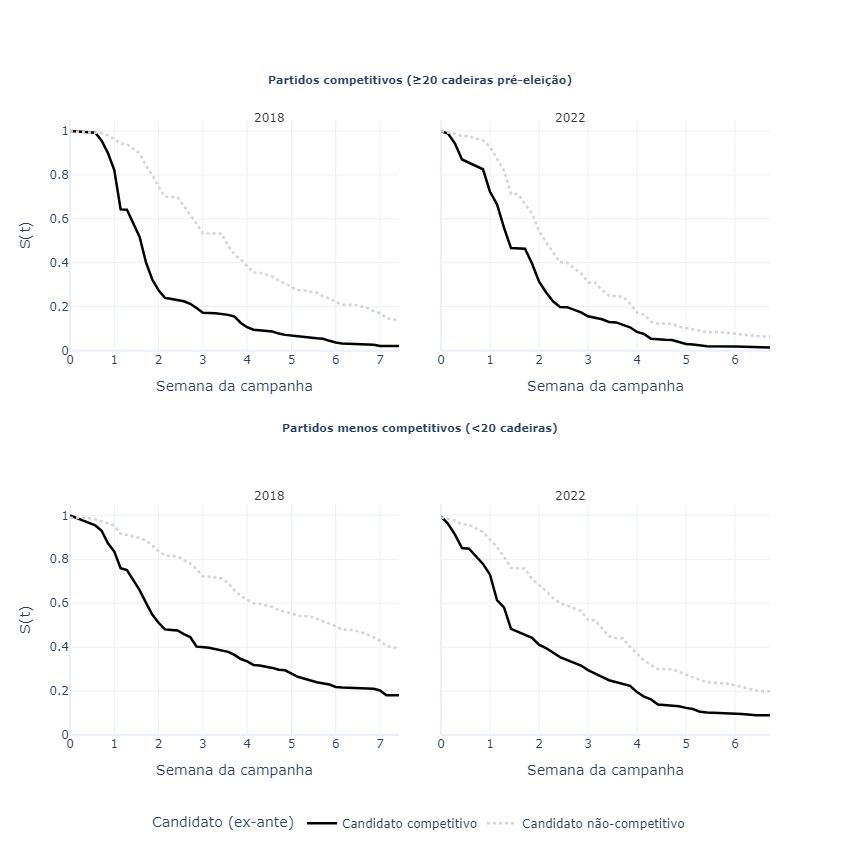

In [13]:

painel_names_maior = [p[0] for p in PAINEIS_MAIOR]

fig_km_maior = make_subplots(
    rows=2, cols=2,
    shared_yaxes=True,
    vertical_spacing=0.25,
    horizontal_spacing=0.06,
)

for i_tipo, tipo in enumerate([True, False]):
    row_offset = i_tipo * 1
    for i_painel, (titulo, d_base) in enumerate(PAINEIS_MAIOR):
        r_bloco, c = POS_BLOCO[i_painel]
        row, col = r_bloco + row_offset, c
        d = d_base[d_base["partido_competitivo"] == tipo].copy()

        for grupo in grupos_km:
            mask = d["grupo_cs"] == grupo
            if mask.sum() < 5:
                continue
            kmf = KaplanMeierFitter()
            kmf.fit(d.loc[mask, "duration_semana"],
                    event_observed=d.loc[mask, "event"], label=grupo)
            sf = kmf.survival_function_
            fig_km_maior.add_trace(
                go.Scatter(
                    x=kmf.timeline, y=sf[grupo].values,
                    mode="lines", name=grupo,
                    legendgroup=grupo,
                    showlegend=(i_tipo == 0 and i_painel == 0),
                    line=dict(color=cores_km[grupo], width=2.5, dash=dashes_km[grupo]),
                ),
                row=row, col=col,
            )

fig_km_maior.add_annotation(
    x=0.5, xref="paper", y=1.08, yref="paper",
    text=f"<b>{TIPO_LABELS[True]}</b>",
    showarrow=False, font=dict(size=11), align="center",
)
fig_km_maior.add_annotation(
    x=0.5, xref="paper", y=0.50, yref="paper",
    text=f"<b>{TIPO_LABELS[False]}</b>",
    showarrow=False, font=dict(size=11), align="center",
)

for y_label in [1.02, 0.39]:
    for x_mid, nome in zip(COL_MIDS, painel_names_maior):
        fig_km_maior.add_annotation(
            x=x_mid, xref="paper", y=y_label, yref="paper",
            text=nome, showarrow=False,
            font=dict(size=12, color="#333"), align="center",
        )

fig_km_maior.update_layout(
    legend=dict(
        title="Candidato (ex-ante)",
        orientation="h", x=0.5, xanchor="center", y=-0.12, yanchor="top",
    ),
    height=850, width=850, template="plotly_white",
    margin=dict(t=120, b=90, l=70),
)
fig_km_maior.update_xaxes(title_text="Semana da campanha", dtick=1)
fig_km_maior.update_yaxes(title_text="S(t)", range=[0, 1.05], col=1)

fig_km_maior.write_image("figs/cap3_survival_km_maior_cs_v2.png", scale=2)
fig_km_maior.show(config={"staticPlot": True})


## Modelos de Duração: Cox PH e Weibull AFT

Estimação controlada do tempo até o primeiro repasse de recursos partidários.

- **Evento:** primeiro repasse FEFC/FP ao candidato
- **SE clusterizados** por partido × UF (`cluster_col='partido_uf'`)
- **Controles:** histórico eleitoral por cargo, proporção de votos intralista t-1, log(magnitude), gênero (mulher) e raça/cor (negra = preta ou parda)

In [14]:

# Cox Proportional Hazards — 2018 | 2022
# HR > 1: covariável aumenta o hazard → candidato recebe antes
# SE clusterizados por partido × UF (cluster_col="partido_uf")

cox_results = {}
for ano, df in survival_dfs.items():
    cph = CoxPHFitter()
    cph.fit(
        df[COVS_MODELO + ["duration", "event", "partido_uf"]],
        duration_col="duration",
        event_col="event",
        cluster_col="partido_uf",
    )
    cox_results[ano] = cph
    print(f"\n=== Cox PH — {ano} ===")
    cph.print_summary(decimals=3)



=== Cox PH — 2018 ===


<lifelines.CoxPHFitter: fitted with 7626 total observations, 2290 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 7626
number of events observed = 5336
   partial log-likelihood = -44768.881
         time fit was run = 2026-06-19 16:50:35 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
n_eleicoes_deputado_federal   0.454     1.575     0.030           0.395           0.514               1.484               1.672
n_eleicoes_deputado_estadual  0.338     1.402     0.038           0.264           0.412               1.302               1.509
n_eleicoes_vereador           0.043     1.044     0.022          -0.001           0.087               0.999               1.091
n_eleicoes_prefeito           0.023     1.024     0.033          -0.041           0.088               0.959               1.092
n_eleicoes_governador         0.728     2.070     0.130           0.472           0.983               1.604               2.673
n_eleicoes_senador            2.041     7.697     0.250           1.550           2.532               4.711              12.574
prop_votos_nominais_lag       0.617     1.854     0.137           0.349           0.886               1.418               2.425
log_qt_vaga                  -0.076     0.926     0.074          -0.221           0.068               0.802               1.070
mulher                        0.339     1.404     0.039           0.263           0.415               1.301               1.515
negra                        -0.119     0.888     0.044          -0.206          -0.032               0.814               0.968

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000 14.964 <0.0005   165.757
n_eleicoes_deputado_estadual   0.000  8.936 <0.0005    61.110
n_eleicoes_vereador            0.000  1.909   0.056     4.152
n_eleicoes_prefeito            0.000  0.708   0.479     1.061
n_eleicoes_governador          0.000  5.584 <0.0005    25.342
n_eleicoes_senador             0.000  8.149 <0.0005    51.272
prop_votos_nominais_lag        0.000  4.509 <0.0005    17.229
log_qt_vaga                    0.000 -1.037   0.300     1.739
mulher                         0.000  8.742 <0.0005    58.593
negra                          0.000 -2.683   0.007     7.101
---
Concordance = 0.585
Partial AIC = 89557.763
log-likelihood ratio test = 701.643 on 10 df
-log2(p) of ll-ratio test = 476.879


=== Cox PH — 2022 ===


<lifelines.CoxPHFitter: fitted with 9616 total observations, 1102 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 9616
number of events observed = 8514
   partial log-likelihood = -71697.327
         time fit was run = 2026-06-19 16:50:37 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
n_eleicoes_deputado_federal   0.319     1.376     0.030           0.261           0.378               1.298               1.459
n_eleicoes_deputado_estadual  0.263     1.301     0.037           0.191           0.336               1.210               1.399
n_eleicoes_vereador           0.014     1.014     0.011          -0.007           0.034               0.993               1.035
n_eleicoes_prefeito           0.012     1.012     0.010          -0.008           0.032               0.992               1.033
n_eleicoes_governador         0.147     1.158     0.195          -0.236           0.529               0.790               1.698
n_eleicoes_senador            0.747     2.111     0.237           0.284           1.211               1.328               3.357
prop_votos_nominais_lag       0.485     1.625     0.151           0.190           0.781               1.209               2.183
log_qt_vaga                   0.030     1.030     0.055          -0.078           0.138               0.925               1.147
mulher                        0.172     1.188     0.023           0.127           0.216               1.136               1.242
negra                        -0.095     0.909     0.033          -0.160          -0.031               0.852               0.970

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000 10.686 <0.0005    86.120
n_eleicoes_deputado_estadual   0.000  7.113 <0.0005    39.675
n_eleicoes_vereador            0.000  1.315   0.188     2.408
n_eleicoes_prefeito            0.000  1.147   0.251     1.993
n_eleicoes_governador          0.000  0.751   0.453     1.143
n_eleicoes_senador             0.000  3.158   0.002     9.299
prop_votos_nominais_lag        0.000  3.221   0.001     9.615
log_qt_vaga                    0.000  0.538   0.590     0.760
mulher                         0.000  7.576 <0.0005    44.676
negra                          0.000 -2.887   0.004     8.006
---
Concordance = 0.562
Partial AIC = 143414.654
log-likelihood ratio test = 520.956 on 10 df
-log2(p) of ll-ratio test = 348.253

In [15]:

print("C-index (concordância) por ano:\n")
for ano, cph in cox_results.items():
    print(f"  {ano}: C = {cph.concordance_index_:.4f}")


C-index (concordância) por ano:

  2018: C = 0.5853
  2022: C = 0.5624


In [16]:

# Weibull AFT — robustez paramétrica (2018 | 2022)
# Coef < 0: tempo acelerado → candidato recebe mais cedo
# WeibullAFTFitter não aceita cluster_col — usa robust=True (HC0)

waf_results = {}
for ano, df in survival_dfs.items():
    d = df.copy()
    d["duration"] = d["duration"].clip(lower=0.5)  # Weibull não aceita duration == 0
    waf = WeibullAFTFitter()
    waf.fit(
        d[COVS_MODELO + ["duration", "event"]],
        duration_col="duration",
        event_col="event",
        robust=True,
    )
    waf_results[ano] = waf
    print(f"\n=== Weibull AFT — {ano} ===")
    waf.print_summary(decimals=3)



=== Weibull AFT — 2018 ===


<lifelines.WeibullAFTFitter: fitted with 7626 total observations, 2290 right-censored observations>
             duration col = 'duration'
                event col = 'event'
          robust variance = True
   number of observations = 7626
number of events observed = 5336
           log-likelihood = -24633.570
         time fit was run = 2026-06-19 16:50:40 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                      
lambda_ log_qt_vaga                   0.082     1.085     0.020           0.043           0.120               1.044               1.128
        mulher                       -0.376     0.687     0.030          -0.435          -0.317               0.648               0.728
        n_eleicoes_deputado_estadual -0.330     0.719     0.033          -0.396          -0.265               0.673               0.767
        n_eleicoes_deputado_federal  -0.438     0.645     0.017          -0.471          -0.405               0.625               0.667
        n_eleicoes_governador        -0.722     0.486     0.117          -0.951          -0.494               0.386               0.610
        n_eleicoes_prefeito          -0.031     0.969     0.038          -0.105           0.042               0.900               1.043
        n_eleicoes_senador           -1.856     0.156     0.229          -2.305          -1.407               0.100               0.245
        n_eleicoes_vereador          -0.042     0.959     0.022          -0.085           0.001               0.919               1.001
        negra                         0.126     1.134     0.030           0.067           0.184               1.069               1.202
        prop_votos_nominais_lag      -0.575     0.563     0.125          -0.820          -0.330               0.441               0.719
        Intercept                     3.554    34.969     0.071           3.415           3.694              30.419              40.198
rho_    Intercept                    -0.035     0.965     0.012          -0.059          -0.011               0.943               0.989

                                      cmp to       z       p  -log2(p)
param   covariate                                                     
lambda_ log_qt_vaga                    0.000   4.150 <0.0005    14.877
        mulher                         0.000 -12.496 <0.0005   116.613
        n_eleicoes_deputado_estadual   0.000  -9.897 <0.0005    74.308
        n_eleicoes_deputado_federal    0.000 -26.289 <0.0005   503.587
        n_eleicoes_governador          0.000  -6.195 <0.0005    30.672
        n_eleicoes_prefeito            0.000  -0.836   0.403     1.311
        n_eleicoes_senador             0.000  -8.098 <0.0005    50.666
        n_eleicoes_vereador            0.000  -1.914   0.056     4.168
        negra                          0.000   4.183 <0.0005    15.086
        prop_votos_nominais_lag        0.000  -4.604 <0.0005    17.883
        Intercept                      0.000  49.986 <0.0005       inf
rho_    Intercept                      0.000  -2.888   0.004     8.010
---
Concordance = 0.585
AIC = 49291.140
log-likelihood ratio test = 662.484 on 10 df
-log2(p) of ll-ratio test = 448.962


=== Weibull AFT — 2022 ===


<lifelines.WeibullAFTFitter: fitted with 9616 total observations, 1102 right-censored observations>
             duration col = 'duration'
                event col = 'event'
          robust variance = True
   number of observations = 9616
number of events observed = 8514
           log-likelihood = -33302.062
         time fit was run = 2026-06-19 16:51:31 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                      
lambda_ log_qt_vaga                  -0.039     0.962     0.015          -0.068          -0.011               0.935               0.989
        mulher                       -0.189     0.828     0.022          -0.232          -0.145               0.793               0.865
        n_eleicoes_deputado_estadual -0.235     0.790     0.030          -0.294          -0.177               0.746               0.838
        n_eleicoes_deputado_federal  -0.283     0.753     0.020          -0.323          -0.244               0.724               0.784
        n_eleicoes_governador        -0.132     0.876     0.173          -0.471           0.207               0.624               1.230
        n_eleicoes_prefeito          -0.014     0.986     0.009          -0.031           0.004               0.969               1.004
        n_eleicoes_senador           -0.653     0.521     0.173          -0.991          -0.314               0.371               0.731
        n_eleicoes_vereador          -0.013     0.987     0.011          -0.034           0.009               0.966               1.009
        negra                         0.076     1.078     0.022           0.033           0.119               1.033               1.126
        prop_votos_nominais_lag      -0.383     0.682     0.128          -0.634          -0.133               0.531               0.876
        Intercept                     3.161    23.598     0.052           3.059           3.263              21.304              26.140
rho_    Intercept                     0.098     1.103     0.009           0.081           0.116               1.084               1.123

                                      cmp to       z       p  -log2(p)
param   covariate                                                     
lambda_ log_qt_vaga                    0.000  -2.688   0.007     7.121
        mulher                         0.000  -8.425 <0.0005    54.619
        n_eleicoes_deputado_estadual   0.000  -7.873 <0.0005    48.043
        n_eleicoes_deputado_federal    0.000 -14.038 <0.0005   146.296
        n_eleicoes_governador          0.000  -0.764   0.445     1.169
        n_eleicoes_prefeito            0.000  -1.558   0.119     3.069
        n_eleicoes_senador             0.000  -3.777 <0.0005    12.621
        n_eleicoes_vereador            0.000  -1.165   0.244     2.034
        negra                          0.000   3.443   0.001    10.763
        prop_votos_nominais_lag        0.000  -2.997   0.003     8.519
        Intercept                      0.000  60.568 <0.0005       inf
rho_    Intercept                      0.000  10.894 <0.0005    89.391
---
Concordance = 0.562
AIC = 66628.125
log-likelihood ratio test = 513.443 on 10 df
-log2(p) of ll-ratio test = 342.917

In [17]:

def extrair_cox(cph, ano):
    s = cph.summary.reset_index().rename(columns={"covariate": "variavel"})
    s["ano"] = ano
    return s[["variavel", "ano", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]


df_cox_tese = pd.concat([extrair_cox(cph, ano) for ano, cph in cox_results.items()])
df_cox_tese.to_parquet("data/processed/df_cox_survival.parquet", index=False)
print(f"Salvo: {len(df_cox_tese)} linhas | anos: {sorted(df_cox_tese['ano'].unique())}")
print(df_cox_tese.groupby("ano").size().rename("n_coeficientes"))


Salvo: 20 linhas | anos: [2018, 2022]
ano
2018    10
2022    10
Name: n_coeficientes, dtype: int64


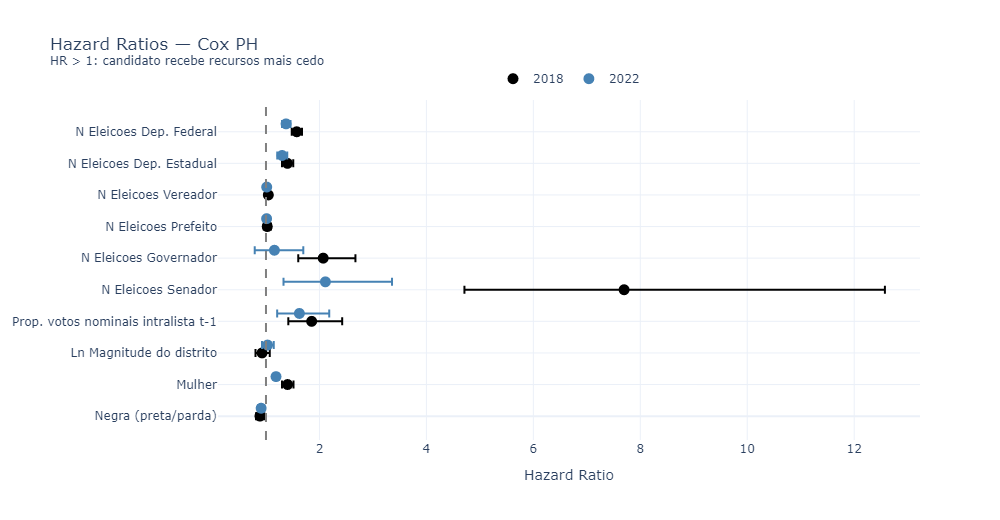

In [18]:
# Hazard Ratios — Cox PH — 2014 | 2018 | 2022

labels_vars = {
    "n_eleicoes_deputado_federal":  "N Eleicoes Dep. Federal",
    "n_eleicoes_deputado_estadual": "N Eleicoes Dep. Estadual",
    "n_eleicoes_vereador":          "N Eleicoes Vereador",
    "n_eleicoes_prefeito":          "N Eleicoes Prefeito",
    "n_eleicoes_governador":        "N Eleicoes Governador",
    "n_eleicoes_senador":           "N Eleicoes Senador",
    "prop_votos_nominais_lag":      "Prop. votos nominais intralista t-1",
    "log_qt_vaga":                  "Ln Magnitude do distrito",
    "mulher":                       "Mulher",
    "negra":                        "Negra (preta/parda)",
}

vars_ordem  = list(labels_vars.values())[::-1]
cores_anos  = {2014: "#aaaaaa", 2018: "black", 2022: "steelblue"}
offsets     = {2014: -0.25, 2018: 0.0, 2022: 0.25}

fig_hr = go.Figure()
for ano, cph in cox_results.items():
    s = cph.summary.reset_index().rename(columns={"covariate": "variavel"})
    s["label"] = s["variavel"].map(labels_vars)
    s["y_pos"] = s["label"].map(
        {v: i + offsets[ano] for i, v in enumerate(vars_ordem)}
    )
    label_str = f"{ano}" + (" (pré-FEFC)" if ano == 2014 else "")
    fig_hr.add_trace(go.Scatter(
        x=s["exp(coef)"],
        y=s["y_pos"],
        mode="markers",
        name=label_str,
        marker=dict(color=cores_anos[ano], size=11, symbol="circle"),
        error_x=dict(
            type="data", symmetric=False,
            array     =(s["exp(coef) upper 95%"] - s["exp(coef)"]).tolist(),
            arrayminus=(s["exp(coef)"] - s["exp(coef) lower 95%"]).tolist(),
            color=cores_anos[ano],
        ),
    ))

fig_hr.add_vline(x=1, line_dash="dash", line_color="grey")
fig_hr.update_layout(
    title="Hazard Ratios — Cox PH<br><sup>HR > 1: candidato recebe recursos mais cedo</sup>",
    xaxis_title="Hazard Ratio",
    yaxis=dict(tickmode="array", tickvals=list(range(len(vars_ordem))), ticktext=vars_ordem),
    template="plotly_white",
    width=1000, height=520,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
)
fig_hr.show()

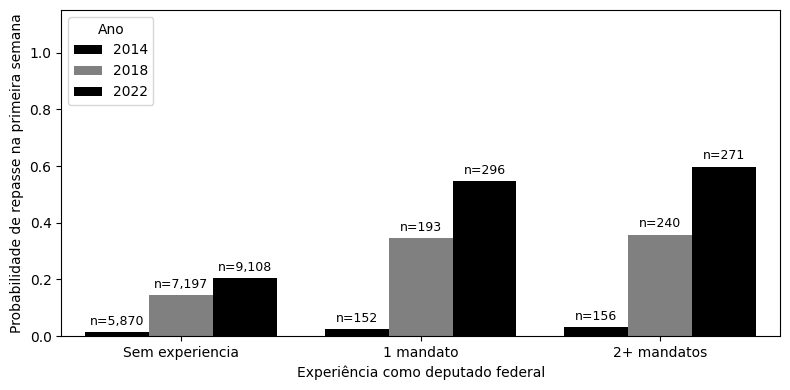

In [19]:
# Probabilidade de repasse na 1ª semana — por experiência como Dep. Federal

df_plot = (
    rrd_df
    .groupby(["exp_deputado_federal", "ano_eleicao"], observed=True)
    .agg(prob_repasse=("repasse_semana1", "mean"), n_obs=("repasse_semana1", "count"))
    .reset_index()
)

fig_bar, ax = plt.subplots(figsize=(8, 4))
ax = sns.barplot(
    data=df_plot,
    x="exp_deputado_federal",
    y="prob_repasse",
    hue="ano_eleicao",
    palette=["black", "grey"],
    ax=ax,
)
for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        for _, row in df_plot.iterrows():
            if abs(height - row["prob_repasse"]) < 0.001:
                labels.append(f"n={row['n_obs']:,.0f}")
                break
        else:
            labels.append("")
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

ax.set_ylabel("Probabilidade de repasse na primeira semana")
ax.set_xlabel("Experiência como deputado federal")
ax.set_ylim(0, 1.15)
ax.legend(title="Ano", loc="upper left")
plt.tight_layout()
plt.show()

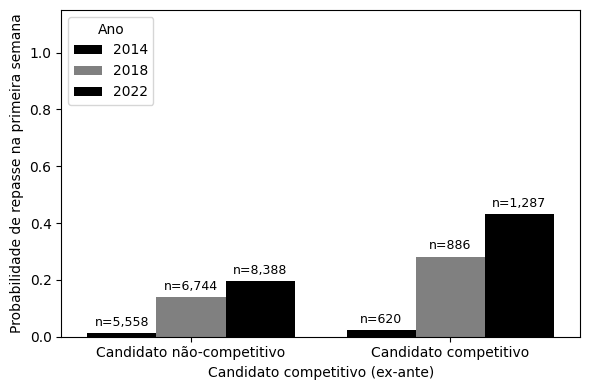

In [20]:
# Probabilidade de repasse na 1ª semana — competitivo vs. não-competitivo (ex-ante)

df_plot_cs = (
    rrd_df.groupby(["candidato_competitivo", "ano_eleicao"], observed=True)
    .agg(prob_repasse=("repasse_semana1", "mean"), n_obs=("repasse_semana1", "count"))
    .reset_index()
)
df_plot_cs["grupo_cs"] = df_plot_cs["candidato_competitivo"].map(
    {True: "Candidato competitivo", False: "Candidato não-competitivo"}
)

fig_bar2, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(
    data=df_plot_cs,
    x="grupo_cs",
    y="prob_repasse",
    hue="ano_eleicao",
    palette=["black", "grey"],
    ax=ax,
)
for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        for _, row in df_plot_cs.iterrows():
            if abs(height - row["prob_repasse"]) < 0.001:
                labels.append(f"n={row['n_obs']:,.0f}")
                break
        else:
            labels.append("")
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

ax.set_ylabel("Probabilidade de repasse na primeira semana")
ax.set_xlabel("Candidato competitivo (ex-ante)")
ax.set_ylim(0, 1.15)
ax.legend(title="Ano", loc="upper left")
plt.tight_layout()
plt.show()

## Robustez: Cox PH com Timing do Maior Repasse

Mesma especificação do modelo principal, mas usando como evento o dia do **maior repasse** diário de recursos partidários (FP/PJ_ROTEADO/FEFC).
`survival_maior` já construído acima com `preparar_survival_maior()`.

In [21]:

# Cox PH com timing do maior repasse — 2018 | 2022

cox_maior = {}
for ano, df in survival_maior.items():
    cph = CoxPHFitter()
    cph.fit(
        df[COVS_MODELO + ["duration", "event", "partido_uf"]],
        duration_col="duration",
        event_col="event",
        cluster_col="partido_uf",
    )
    cox_maior[ano] = cph
    print(f"\n=== Cox PH [maior repasse] — {ano} ===")
    cph.print_summary(decimals=3)

print("\nC-index (maior repasse):")
for ano, cph in cox_maior.items():
    print(f"  {ano}: C = {cph.concordance_index_:.4f}")



=== Cox PH [maior repasse] — 2018 ===


<lifelines.CoxPHFitter: fitted with 7626 total observations, 2345 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 7626
number of events observed = 5281
   partial log-likelihood = -44294.767
         time fit was run = 2026-06-19 16:52:24 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
n_eleicoes_deputado_federal   0.520     1.681     0.038           0.445           0.594               1.560               1.812
n_eleicoes_deputado_estadual  0.400     1.492     0.042           0.317           0.483               1.373               1.621
n_eleicoes_vereador           0.059     1.061     0.018           0.024           0.095               1.024               1.100
n_eleicoes_prefeito           0.058     1.060     0.040          -0.021           0.137               0.979               1.147
n_eleicoes_governador         0.752     2.121     0.224           0.313           1.191               1.368               3.289
n_eleicoes_senador            2.560    12.936     0.306           1.961           3.159               7.107              23.548
prop_votos_nominais_lag       0.479     1.615     0.190           0.108           0.851               1.114               2.341
log_qt_vaga                  -0.089     0.915     0.069          -0.224           0.045               0.800               1.046
mulher                        0.270     1.309     0.034           0.204           0.335               1.226               1.398
negra                        -0.039     0.962     0.047          -0.130           0.052               0.878               1.054

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000 13.606 <0.0005   137.633
n_eleicoes_deputado_estadual   0.000  9.457 <0.0005    68.092
n_eleicoes_vereador            0.000  3.291   0.001     9.966
n_eleicoes_prefeito            0.000  1.435   0.151     2.723
n_eleicoes_governador          0.000  3.359   0.001    10.319
n_eleicoes_senador             0.000  8.377 <0.0005    54.028
prop_votos_nominais_lag        0.000  2.528   0.011     6.445
log_qt_vaga                    0.000 -1.298   0.194     2.363
mulher                         0.000  8.041 <0.0005    49.991
negra                          0.000 -0.838   0.402     1.316
---
Concordance = 0.585
Partial AIC = 88609.533
log-likelihood ratio test = 797.545 on 10 df
-log2(p) of ll-ratio test = 545.320


=== Cox PH [maior repasse] — 2022 ===


<lifelines.CoxPHFitter: fitted with 9616 total observations, 1298 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 9616
number of events observed = 8318
   partial log-likelihood = -70358.335
         time fit was run = 2026-06-19 16:52:26 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
n_eleicoes_deputado_federal   0.296     1.344     0.031           0.234           0.357               1.264               1.429
n_eleicoes_deputado_estadual  0.270     1.310     0.036           0.199           0.341               1.220               1.406
n_eleicoes_vereador           0.014     1.014     0.011          -0.007           0.036               0.993               1.037
n_eleicoes_prefeito           0.006     1.006     0.008          -0.009           0.021               0.992               1.022
n_eleicoes_governador         0.271     1.311     0.202          -0.125           0.667               0.882               1.948
n_eleicoes_senador            0.666     1.946     0.291           0.095           1.237               1.099               3.446
prop_votos_nominais_lag       0.279     1.322     0.160          -0.035           0.594               0.966               1.811
log_qt_vaga                  -0.052     0.949     0.047          -0.143           0.040               0.866               1.040
mulher                        0.126     1.134     0.024           0.078           0.174               1.081               1.190
negra                        -0.026     0.974     0.038          -0.101           0.048               0.904               1.049

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000  9.446 <0.0005    67.951
n_eleicoes_deputado_estadual   0.000  7.433 <0.0005    43.103
n_eleicoes_vereador            0.000  1.284   0.199     2.327
n_eleicoes_prefeito            0.000  0.841   0.400     1.320
n_eleicoes_governador          0.000  1.339   0.181     2.470
n_eleicoes_senador             0.000  2.285   0.022     5.485
prop_votos_nominais_lag        0.000  1.743   0.081     3.620
log_qt_vaga                    0.000 -1.110   0.267     1.905
mulher                         0.000  5.149 <0.0005    21.861
negra                          0.000 -0.696   0.487     1.039
---
Concordance = 0.554
Partial AIC = 140736.669
log-likelihood ratio test = 419.904 on 10 df
-log2(p) of ll-ratio test = 276.598


C-index (maior repasse):
  2018: C = 0.5848
  2022: C = 0.5544


In [22]:
# Cox PH [maior repasse por canal] — 2014: Fundo Partidário | PJ → Partido → Cand.
# Objetivo: testar H2b (front-loading do investimento principal) em cada canal separadamente.
# FP: ~491 eventos (8%) — IC largo esperado | PJ_ROTEADO: ~2.027 eventos (33%)

cox_maior_2014_canais = {}
for canal in ["FP", "PJ_ROTEADO"]:
    df_canal = _df_rec_partido[
        (_df_rec_partido["ano_eleicao"] == 2014) & (_df_rec_partido["fonte_tipo"] == canal)
    ]
    df_maior_canal = calcular_dias_maior_receita(df_canal)
    df_s = preparar_survival_maior(rrd_df, df_maior_canal, 2014)

    ev  = int(df_s["event"].sum())
    pct = ev / len(df_s) * 100
    print(f"2014 — {canal}: N={len(df_s):,} | eventos={ev:,} ({pct:.0f}%) | censurados={len(df_s)-ev:,}")

    cph = CoxPHFitter()
    cph.fit(
        df_s[COVS_MODELO + ["duration", "event", "partido_uf"]],
        duration_col="duration",
        event_col="event",
        cluster_col="partido_uf",
    )
    cox_maior_2014_canais[canal] = cph
    print(f"=== Cox PH [maior repasse] — 2014 — {canal} ===")
    cph.print_summary(decimals=3)

print("C-index (maior repasse por canal):")
for canal, cph in cox_maior_2014_canais.items():
    print(f"  2014 — {canal}: C = {cph.concordance_index_:.4f}")


2014 — FP: N=6,176 | eventos=491 (8%) | censurados=5,685
=== Cox PH [maior repasse] — 2014 — FP ===


<lifelines.CoxPHFitter: fitted with 6176 total observations, 5685 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6176
number of events observed = 491
   partial log-likelihood = -4240.310
         time fit was run = 2026-06-19 16:52:30 UTC

---
                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                       
n_eleicoes_deputado_federal    0.049     1.050     0.093          -0.134           0.231               0.875               1.260
n_eleicoes_deputado_estadual  -0.081     0.922     0.147          -0.370           0.208               0.690               1.231
n_eleicoes_vereador           -0.006     0.994     0.042          -0.089           0.076               0.914               1.079
n_eleicoes_prefeito           -0.283     0.754     0.392          -1.051           0.485               0.350               1.625
n_eleicoes_governador          0.879     2.410     0.744          -0.579           2.338               0.560              10.361
n_eleicoes_senador           -12.376     0.000     0.515         -13.386         -11.367               0.000               0.000
prop_votos_nominais_lag        1.719     5.579     0.323           1.086           2.352               2.963              10.504
log_qt_vaga                   -0.014     0.986     0.148          -0.304           0.277               0.738               1.319
mulher                        -0.259     0.771     0.101          -0.458          -0.061               0.632               0.941
negra                         -0.076     0.927     0.144          -0.358           0.207               0.699               1.230

                              cmp to       z       p  -log2(p)
covariate                                                     
n_eleicoes_deputado_federal    0.000   0.522   0.602     0.733
n_eleicoes_deputado_estadual   0.000  -0.551   0.581     0.783
n_eleicoes_vereador            0.000  -0.154   0.878     0.188
n_eleicoes_prefeito            0.000  -0.721   0.471     1.087
n_eleicoes_governador          0.000   1.182   0.237     2.075
n_eleicoes_senador             0.000 -24.032 <0.0005   421.520
prop_votos_nominais_lag        0.000   5.325 <0.0005    23.237
log_qt_vaga                    0.000  -0.092   0.927     0.109
mulher                         0.000  -2.559   0.011     6.573
negra                          0.000  -0.525   0.599     0.738
---
Concordance = 0.557
Partial AIC = 8500.620
log-likelihood ratio test = 50.664 on 10 df
-log2(p) of ll-ratio test = 22.243

2014 — PJ_ROTEADO: N=6,176 | eventos=2,027 (33%) | censurados=4,149
=== Cox PH [maior repasse] — 2014 — PJ_ROTEADO ===


<lifelines.CoxPHFitter: fitted with 6176 total observations, 4149 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6176
number of events observed = 2027
   partial log-likelihood = -17116.661
         time fit was run = 2026-06-19 16:52:32 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
n_eleicoes_deputado_federal   0.462     1.588     0.041           0.383           0.542               1.466               1.720
n_eleicoes_deputado_estadual  0.396     1.486     0.044           0.311           0.481               1.364               1.618
n_eleicoes_vereador           0.008     1.008     0.027          -0.045           0.060               0.956               1.062
n_eleicoes_prefeito          -0.036     0.965     0.031          -0.097           0.026               0.907               1.026
n_eleicoes_governador         0.508     1.662     0.207           0.103           0.913               1.108               2.492
n_eleicoes_senador            0.392     1.479     0.274          -0.145           0.928               0.865               2.529
prop_votos_nominais_lag       0.568     1.764     0.204           0.167           0.968               1.182               2.633
log_qt_vaga                   0.003     1.003     0.087          -0.168           0.174               0.846               1.189
mulher                       -0.048     0.953     0.075          -0.196           0.099               0.822               1.104
negra                        -0.341     0.711     0.060          -0.458          -0.224               0.633               0.799

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000 11.349 <0.0005    96.747
n_eleicoes_deputado_estadual   0.000  9.097 <0.0005    63.222
n_eleicoes_vereador            0.000  0.283   0.777     0.364
n_eleicoes_prefeito            0.000 -1.136   0.256     1.966
n_eleicoes_governador          0.000  2.457   0.014     6.157
n_eleicoes_senador             0.000  1.431   0.152     2.713
prop_votos_nominais_lag        0.000  2.778   0.005     7.512
log_qt_vaga                    0.000  0.034   0.973     0.040
mulher                         0.000 -0.642   0.521     0.941
negra                          0.000 -5.717 <0.0005    26.456
---
Concordance = 0.592
Partial AIC = 34253.322
log-likelihood ratio test = 399.088 on 10 df
-log2(p) of ll-ratio test = 261.875

C-index (maior repasse por canal):
  2014 — FP: C = 0.5571
  2014 — PJ_ROTEADO: C = 0.5923


In [26]:
# Tabela comparativa: HR(primeiro repasse) x HR(maior repasse) — 2014 canais | 2018 | 2022

def extrair_hr(cph, label):
    s = cph.summary[["exp(coef)", "p"]].copy()
    s.columns = [f"HR_{label}", f"p_{label}"]
    return s

covs_display = {
    "n_eleicoes_deputado_federal":  "Mandatos Dep. Federal",
    "n_eleicoes_deputado_estadual": "Mandatos Dep. Estadual",
    "n_eleicoes_prefeito":          "Mandatos Prefeito",
    "n_eleicoes_governador":        "Mandatos Governador",
    "n_eleicoes_senador":           "Mandatos Senador",
    "prop_votos_nominais_lag":      "Prop. votos nominais t-1",
    "log_qt_vaga":                  "log(Magnitude)",
    "mulher":                       "Mulher",
    "negra":                        "Negra (preta/parda)",
}

configs = [
    ("1rep_2018",      cox_results[2018]),
    ("maior_2018",     cox_maior[2018]),
    ("1rep_2022",      cox_results[2022]),
    ("maior_2022",     cox_maior[2022]),
]

tabs = [extrair_hr(cph, lbl) for lbl, cph in configs]
tab_comp = pd.concat(tabs, axis=1).loc[list(covs_display.keys())]
tab_comp.index = tab_comp.index.map(covs_display)

with pd.option_context("display.float_format", "{:.3f}".format, "display.max_columns", 20, "display.width", 200):
    print("Hazard Ratios — primeiro vs. maior repasse")
    print(tab_comp.to_string())

# LaTeX para o capítulo
col_ordem = [
             "1rep_2018", "maior_2018", "1rep_2022", "maior_2022"]

def fmt_hr(hr, p):
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    return f"{hr:.2f}{stars}"

print("% LaTeX (Tabela 4.2)")
print("\begin{tabular}{l" + "r" * len(col_ordem) + "}")
print("\hline")
header = [
          "1º rep.~2018", "maior 2018", "1º rep.~2022", "maior 2022"]
print("  Covariável & " + " & ".join(header) + " \\\\")
print("\hline")
for cov, nome in covs_display.items():
    row_vals = [fmt_hr(tab_comp.loc[nome, f"HR_{lbl}"], tab_comp.loc[nome, f"p_{lbl}"]) for lbl in col_ordem]
    print(f"  {nome} & " + " & ".join(row_vals) + " \\\\")
print("\hline")
print("\end{tabular}")


Hazard Ratios — primeiro vs. maior repasse
                          HR_1rep_2018  p_1rep_2018  HR_maior_2018  p_maior_2018  HR_1rep_2022  p_1rep_2022  HR_maior_2022  p_maior_2022
covariate                                                                                                                               
Mandatos Dep. Federal            1.575        0.000          1.681         0.000         1.376        0.000          1.344         0.000
Mandatos Dep. Estadual           1.402        0.000          1.492         0.000         1.301        0.000          1.310         0.000
Mandatos Prefeito                1.024        0.479          1.060         0.151         1.012        0.251          1.006         0.400
Mandatos Governador              2.070        0.000          2.121         0.001         1.158        0.453          1.311         0.181
Mandatos Senador                 7.697        0.000         12.936         0.000         2.111        0.002          1.946         0.02